In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', names=["label", "message"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64


In [ ]:
print("\nClass Distribution:")
print(df["label"].value_counts())

print("\nClass Percentage:")
print(df["label"].value_counts(normalize=True) * 100)


Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


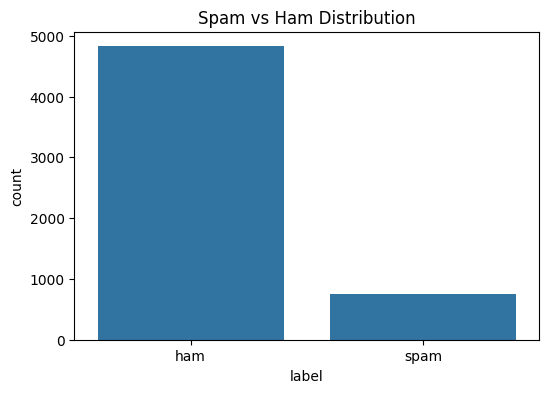

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [ ]:
df["message_length"] = df["message"].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
print("\nMessage Length Statistics:")
print(df["message_length"].describe())


Message Length Statistics:
count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: message_length, dtype: float64


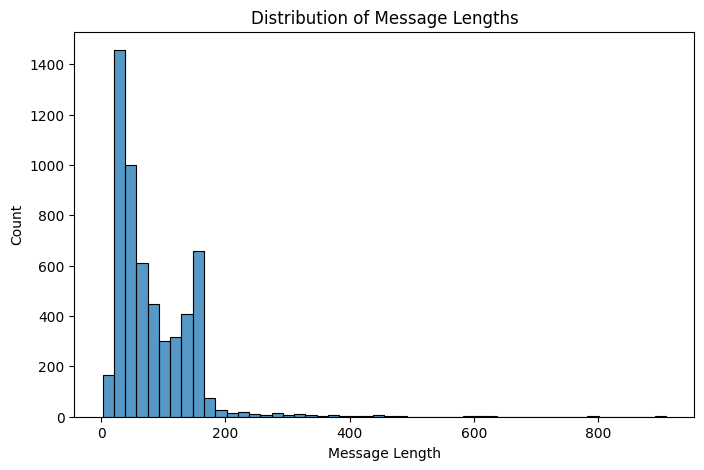

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["message_length"], bins=50)
plt.title("Distribution of Message Lengths")
plt.xlabel("Message Length")
plt.show()

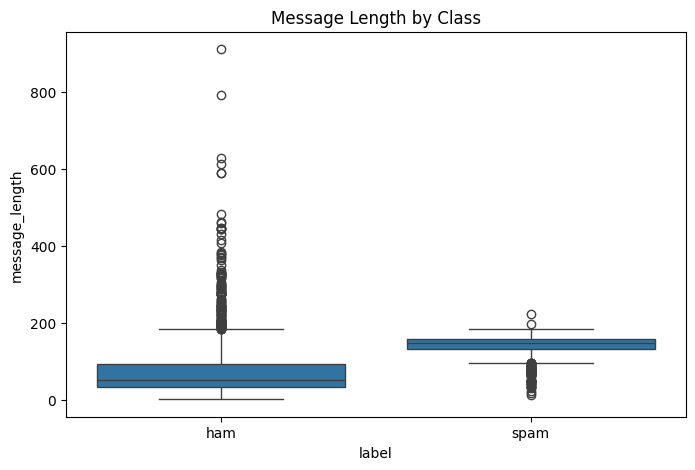

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="message_length", data=df)
plt.title("Message Length by Class")
plt.show()

Spam messages tend to be longer than ham messages.


In [ ]:
from collections import Counter
import re

all_words = " ".join(df["message"]).lower()
words = re.findall(r'\b\w+\b', all_words)

word_counts = Counter(words)

print(word_counts.most_common(20))

[('i', 3021), ('to', 2253), ('you', 2245), ('a', 1450), ('the', 1339), ('u', 1207), ('and', 980), ('in', 903), ('is', 897), ('me', 807), ('my', 766), ('it', 752), ('for', 711), ('your', 681), ('of', 623), ('call', 593), ('that', 586), ('s', 580), ('have', 578), ('on', 538)]


In [ ]:
spam_words = " ".join(df[df["label"]=="spam"]["message"]).lower()
spam_words = re.findall(r'\b\w+\b', spam_words)

Counter(spam_words).most_common(20)

[('to', 691),
 ('a', 380),
 ('call', 355),
 ('you', 297),
 ('your', 264),
 ('free', 224),
 ('2', 207),
 ('the', 206),
 ('for', 204),
 ('now', 199),
 ('or', 188),
 ('u', 174),
 ('txt', 163),
 ('is', 158),
 ('on', 145),
 ('ur', 144),
 ('4', 137),
 ('have', 135),
 ('from', 131),
 ('mobile', 127)]

In [ ]:
ham_words = " ".join(df[df["label"]=="ham"]["message"]).lower()
ham_words = re.findall(r'\b\w+\b', ham_words)

Counter(ham_words).most_common(20)

[('i', 2960),
 ('you', 1948),
 ('to', 1562),
 ('the', 1133),
 ('a', 1070),
 ('u', 1033),
 ('and', 858),
 ('in', 823),
 ('me', 777),
 ('my', 754),
 ('is', 739),
 ('it', 718),
 ('that', 560),
 ('of', 526),
 ('for', 507),
 ('s', 490),
 ('have', 443),
 ('can', 441),
 ('but', 441),
 ('so', 436)]

In [ ]:
print("Average Ham Length:",
      df[df["label"]=="ham"]["message_length"].mean())

print("Average Spam Length:",
      df[df["label"]=="spam"]["message_length"].mean())

Average Ham Length: 71.48248704663213
Average Spam Length: 138.6706827309237
